# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

### <span style="color:cyan">Daniela Higuita Agudelo :)

## Carga y comprensión de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo de datos.

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

#### <span style="color:cyan">Cargando el archivo

In [1]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'athlete_events.csv'

df = pd.read_csv(DATA_DIR / file_path)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [3]:
df.describe() #Numéricas

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [4]:
df.describe(include='object').T #Categoricas

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


#### <span style="color:cyan">Datos duplicados

In [5]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  1385


#### <span style="color:cyan">Datos nulos

In [6]:
df.isnull().sum().sort_values(ascending=False).head(5)

Medal     231333
Weight     62875
Height     60171
Age         9474
Sex            0
dtype: int64

#### <span style="color:cyan">El dataset tiene 15 variables y 271116 registros.

#### <span style="color:cyan">Las variables Age y Height debe ser tipo int y no float, ya que revisando el archivo no se encuentran valores con decimales. Puede pasar que dice tipo float porque en estás variables hay datos nulos.

#### <span style="color:cyan">Los datos numéricos encontrados en el dataset son: ID, Age, Height, Weight y Year.

#### <span style="color:cyan">Los datos numéricos encontrados en el dataset son: Name, Sex, Team, NOC, Games, Season, City, Sport, Event y Medal.

#### <span style="color:cyan">Hay 1385 datos duplicados en el dataset.

#### <span style="color:cyan">Las variables que tienen datos nulos son Medal-231333, Weight-62875, Height-60171 y Age-9474

Descarte las variables que considere irrelevantes para su modelo (p.e. claves primarias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

#### <span style="color:cyan">A continuación se descarta la variable ID porque es primaria, Name tiene en su gran mayoría datos iguales, las variables Team y NOC son redundantes en su mayoría también así que solo se dejara Team y la variable Games porque es redundante, ya que las variables Year y Season tiene su contenido.

In [7]:
df = df.drop(columns=['ID', 'Name', 'NOC', 'Games']) 
df.head()

,Sex,Age,Height,Weight,Team,Year,Season,City,Sport,Event,Medal
0,M,24.0,180.0,80.0,China,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,M,23.0,170.0,60.0,China,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,M,24.0,NaN,NaN,Denmark,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,M,34.0,NaN,NaN,Denmark/Sweden,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,F,21.0,185.0,82.0,Netherlands,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


#### <span style="color:cyan">Gestionando datos duplicados

In [8]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  11264


In [9]:
df = df.drop_duplicates()
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


#### <span style="color:cyan">Gestionando datos nulos

In [10]:
df[['Medal', 'Weight', 'Height', 'Age']].isnull().sum()*100/df.shape[0]

Medal     85.255838
Weight    20.001770
Height    18.962717
Age        1.991903
dtype: float64

#### <span style="color:cyan">Imputando No medal

In [11]:
df['Medal'].fillna(value='No medal').loc[37:45]

37      Bronze
38      Bronze
39    No medal
40      Bronze
41      Bronze
42        Gold
43    No medal
44        Gold
45    No medal
Name: Medal, dtype: object

#### <span style="color:cyan">Analizando el porcentaje de los datos nulos que tienen las variables Wight, Height y Age, es bajo así que estos registros con datos nulos se pueden eliminar

In [12]:
df=df.dropna(subset=['Weight', 'Height', 'Age'])

#### <span style="color:cyan">En el punto anterior explique que Age y Height debían ser tipo int y no float, y eliminando los datos nulos y duplicados ahora es posible realizar un cambio de estas variables

In [13]:
df['Age'] = df['Age'].astype(int)
df['Height'] = df['Height'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205846 entries, 0 to 271115
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     205846 non-null  object 
 1   Age     205846 non-null  int64  
 2   Height  205846 non-null  int64  
 3   Weight  205846 non-null  float64
 4   Team    205846 non-null  object 
 5   Year    205846 non-null  int64  
 6   Season  205846 non-null  object 
 7   City    205846 non-null  object 
 8   Sport   205846 non-null  object 
 9   Event   205846 non-null  object 
 10  Medal   30132 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 18.8+ MB


## Análisis de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

In [14]:
df.describe(include='object').T

,count,unique,top,freq
Sex,205846,2,M,139212
Team,205846,660,United States,13662
Season,205846,2,Summer,166453
City,205846,42,London,13784
Sport,205846,56,Athletics,32354
Event,205846,590,Ice Hockey Men's Ice Hockey,3798
Medal,30132,3,Gold,10149


--- Análisis de Weight según Sex ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_25412\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


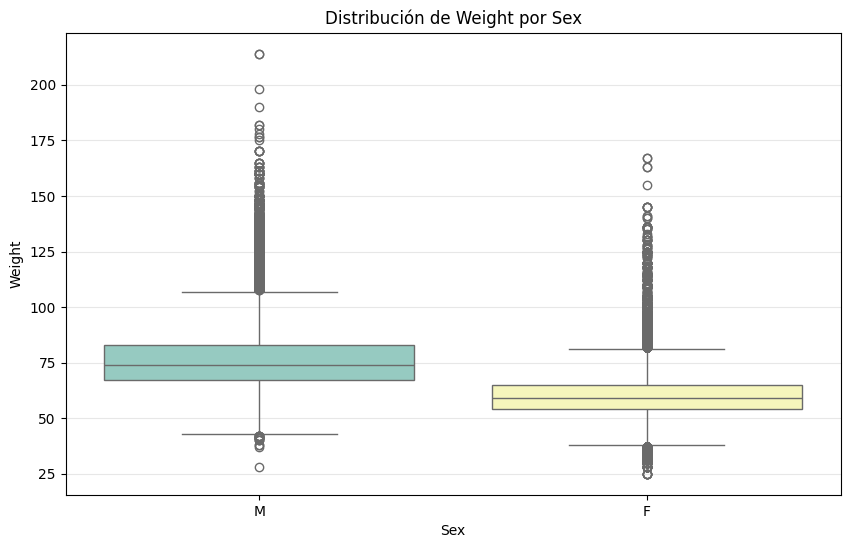

,Weight
Sex,
M,75.789953
F,60.025197


--------------------------------------------------
--- Análisis de Weight según Team ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_25412\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


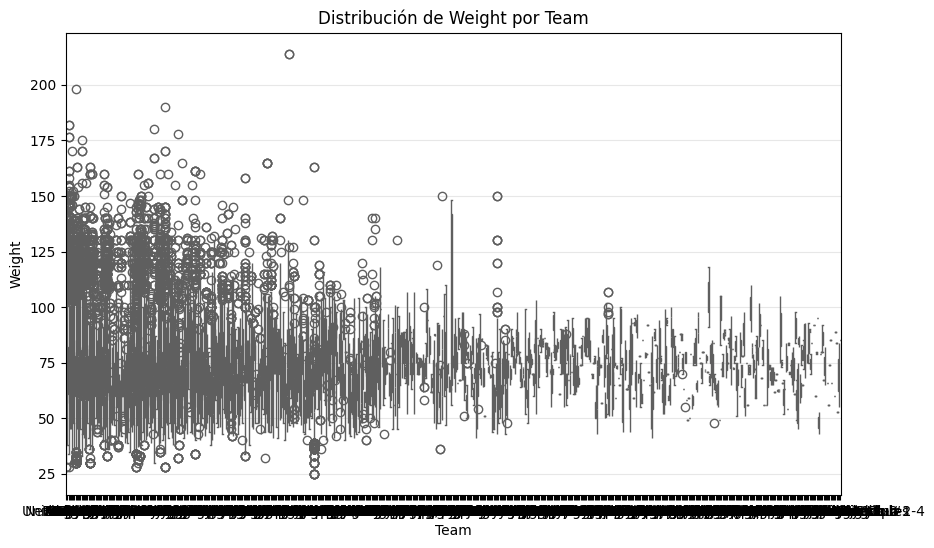

,Weight
Team,
Kathleen,104.500000
Maryke,99.500000
London City Police-1,99.000000
Nauru,98.090909
Puerto Rico-2,98.000000
...,...
Elvis Va,51.000000
Rambo,50.000000
Brentina,49.000000


--------------------------------------------------
--- Análisis de Weight según Season ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_25412\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


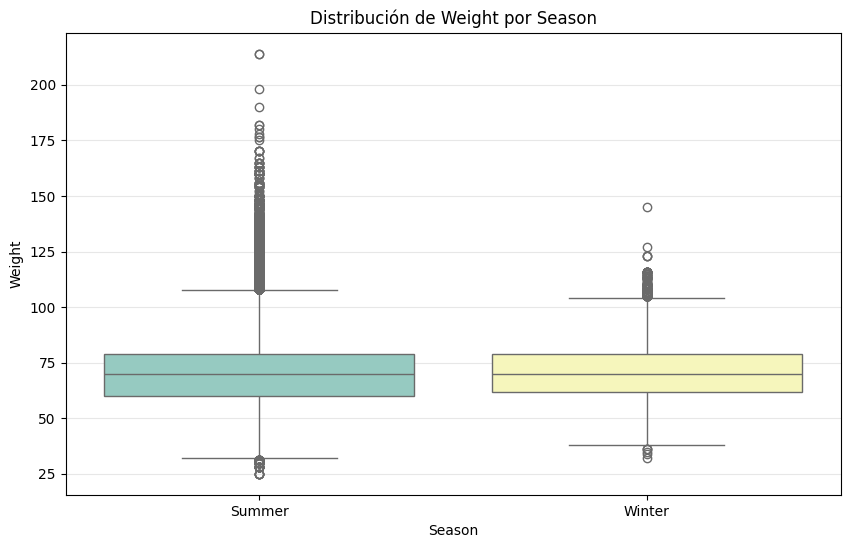

,Weight
Season,
Winter,70.748966
Summer,70.672058


--------------------------------------------------
--- Análisis de Weight según City ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_25412\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


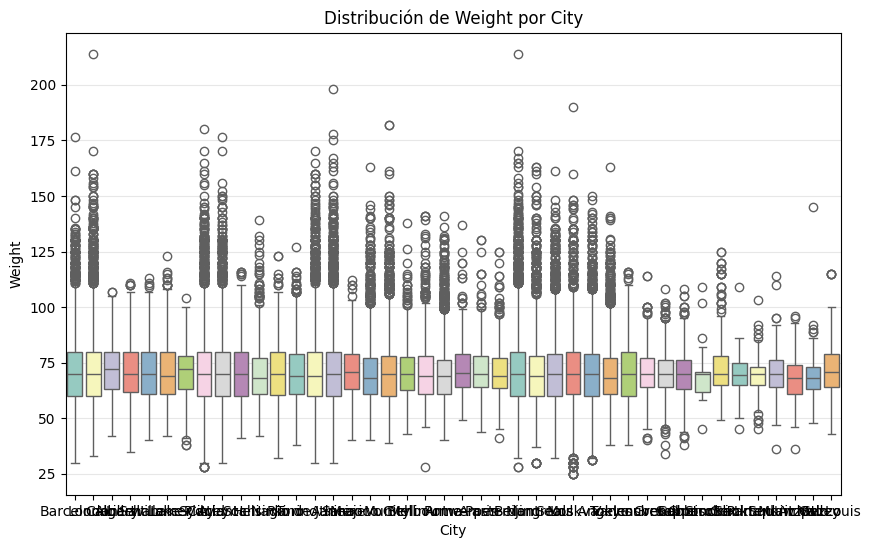

,Weight
City,
St. Louis,73.310924
Stockholm,72.586890
Antwerpen,72.091335
Calgary,71.985360
Paris,71.727124
London,71.463654
Berlin,71.428053
Beijing,71.392876
Athina,71.363977


--------------------------------------------------
--- Análisis de Weight según Sport ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_25412\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


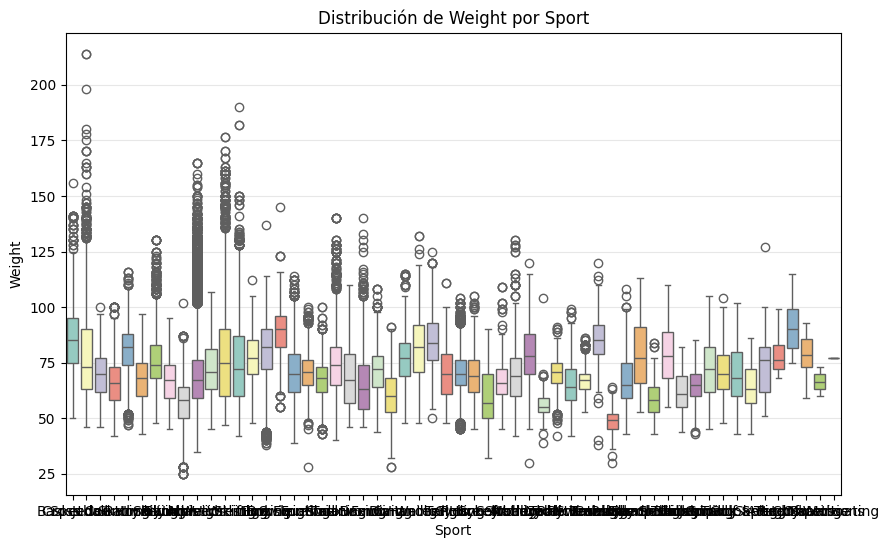

,Weight
Sport,
Tug-Of-War,91.800000
Bobsleigh,89.171059
Basketball,85.791952
Baseball,85.721165
Water Polo,84.569270
Handball,81.499849
Ice Hockey,80.835900
Rowing,80.174807
Weightlifting,79.620753


--------------------------------------------------
--- Análisis de Weight según Event ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_25412\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


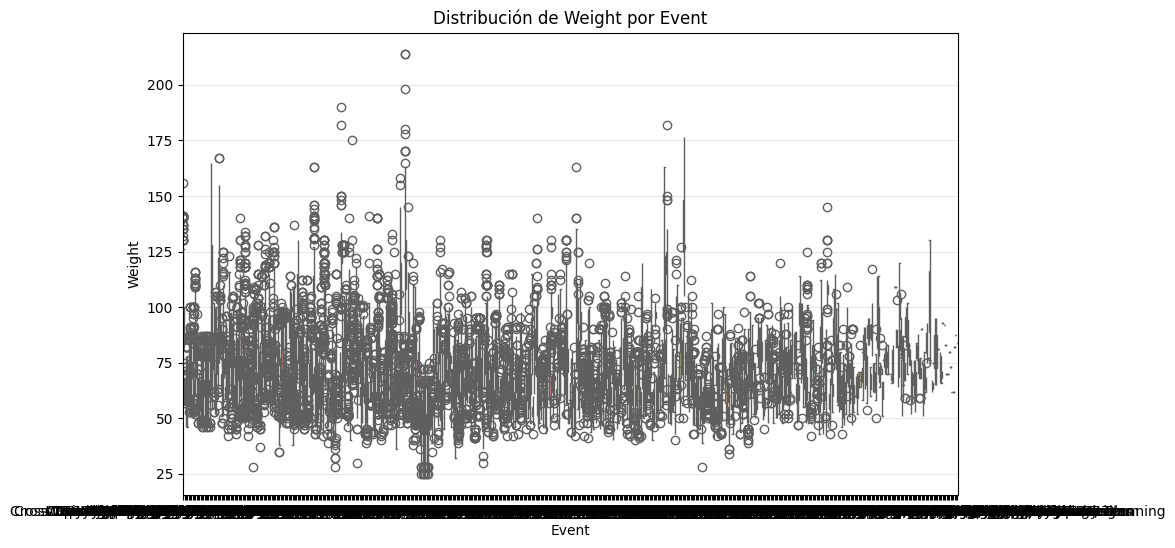

,Weight
Event,
Weightlifting Men's Super-Heavyweight,136.354396
"Wrestling Men's Super-Heavyweight, Greco-Roman",122.161290
Judo Men's Heavyweight,120.563973
"Wrestling Men's Super-Heavyweight, Freestyle",118.756614
Athletics Men's Shot Put,115.421603
...,...
Gymnastics Women's Floor Exercise,47.873572
Gymnastics Women's Uneven Bars,47.798485
Gymnastics Women's Individual All-Around,47.707925


--------------------------------------------------
--- Análisis de Weight según Medal ---


C:\Users\dagud\AppData\Local\Temp\ipykernel_25412\2339564643.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


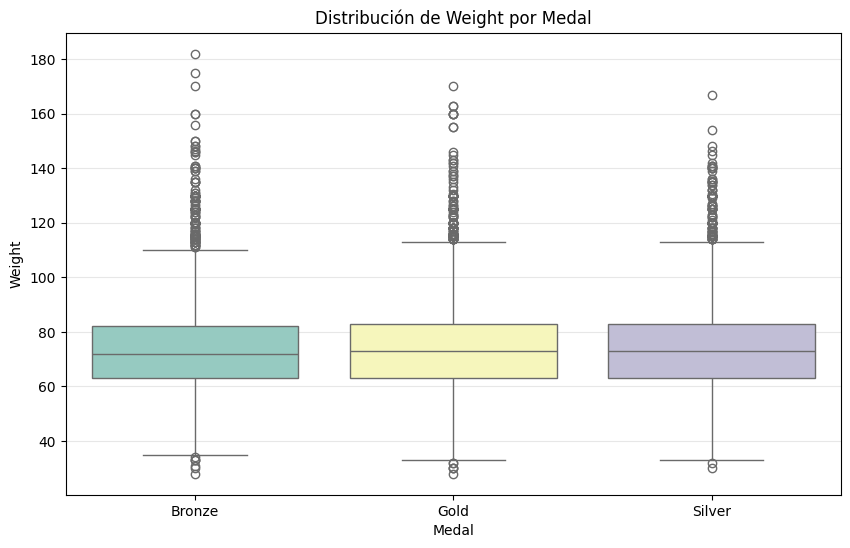

,Weight
Medal,
Gold,74.122130
Silver,73.624771
Bronze,73.488803


--------------------------------------------------


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_vars = df.select_dtypes(include=['object']).columns.tolist()
for var in cat_vars:
    print(f"--- Análisis de Weight según {var} ---")
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=var, y='Weight', palette='Set3')
    plt.title(f'Distribución de Weight por {var}')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    # Mostramos la media de peso por categoría para confirmar
    display(df.groupby(var)['Weight'].mean().to_frame().sort_values(by='Weight', ascending=False))
    print("-" * 50)

#### <span style="color:cyan">Analizando el dataset y las gráficas anteriores se puede identificar que:

#### <span style="color:cyan">Las variables Nominales son: Sex, Season, City, Sport

#### <span style="color:cyan">Las variables Ordinales: Medal

#### <span style="color:cyan">Las variables con alta cardinalidad: Team y Event

#### <span style="color:cyan">Analizando los boxplot se puede ver que las variables que no son aptas para usar en la matriz de caracteristicas son Medal, City y Season.


## Análisis de variables cuantitativas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

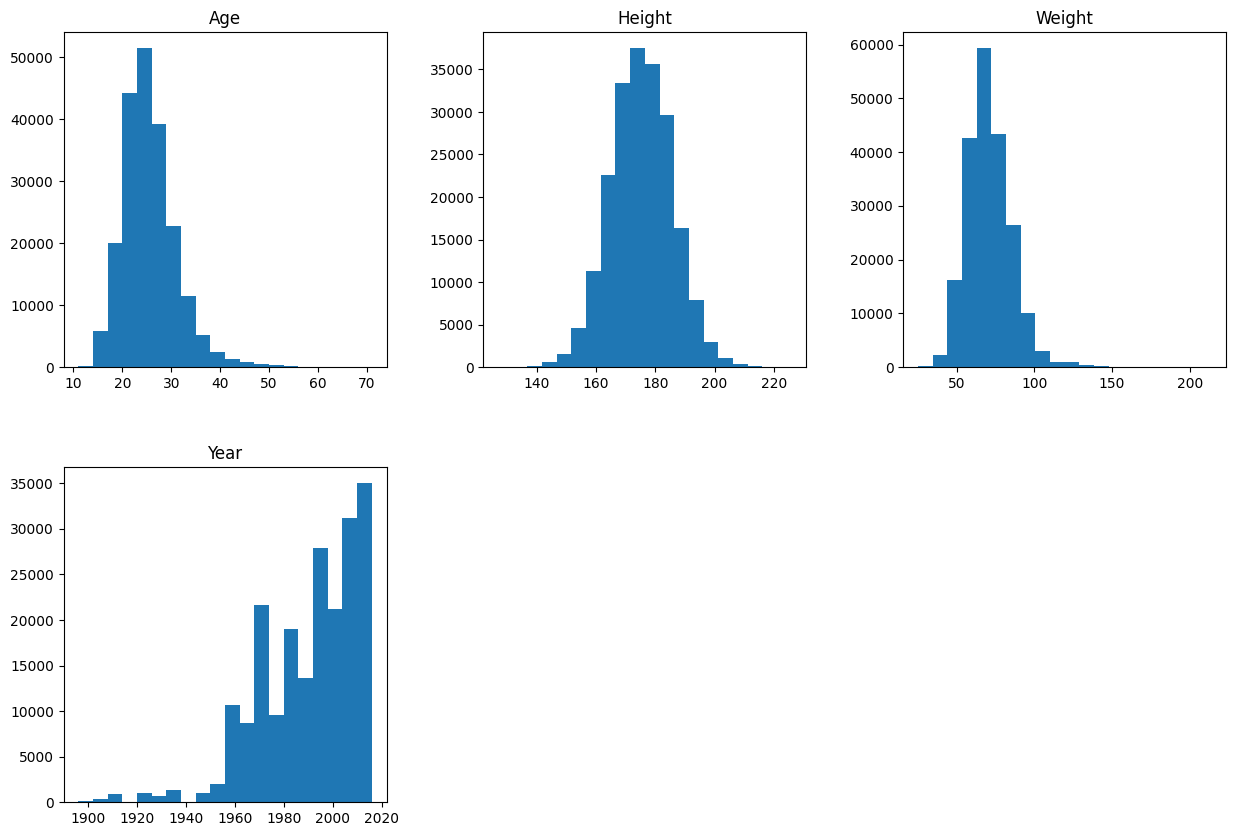

In [16]:
df.select_dtypes('number').hist(bins=20, figsize=(15,10), grid=False, layout=(2,3));

Age          Axes(0.125,0.53;0.227941x0.35)
Height    Axes(0.398529,0.53;0.227941x0.35)
Weight    Axes(0.672059,0.53;0.227941x0.35)
Year         Axes(0.125,0.11;0.227941x0.35)
dtype: object

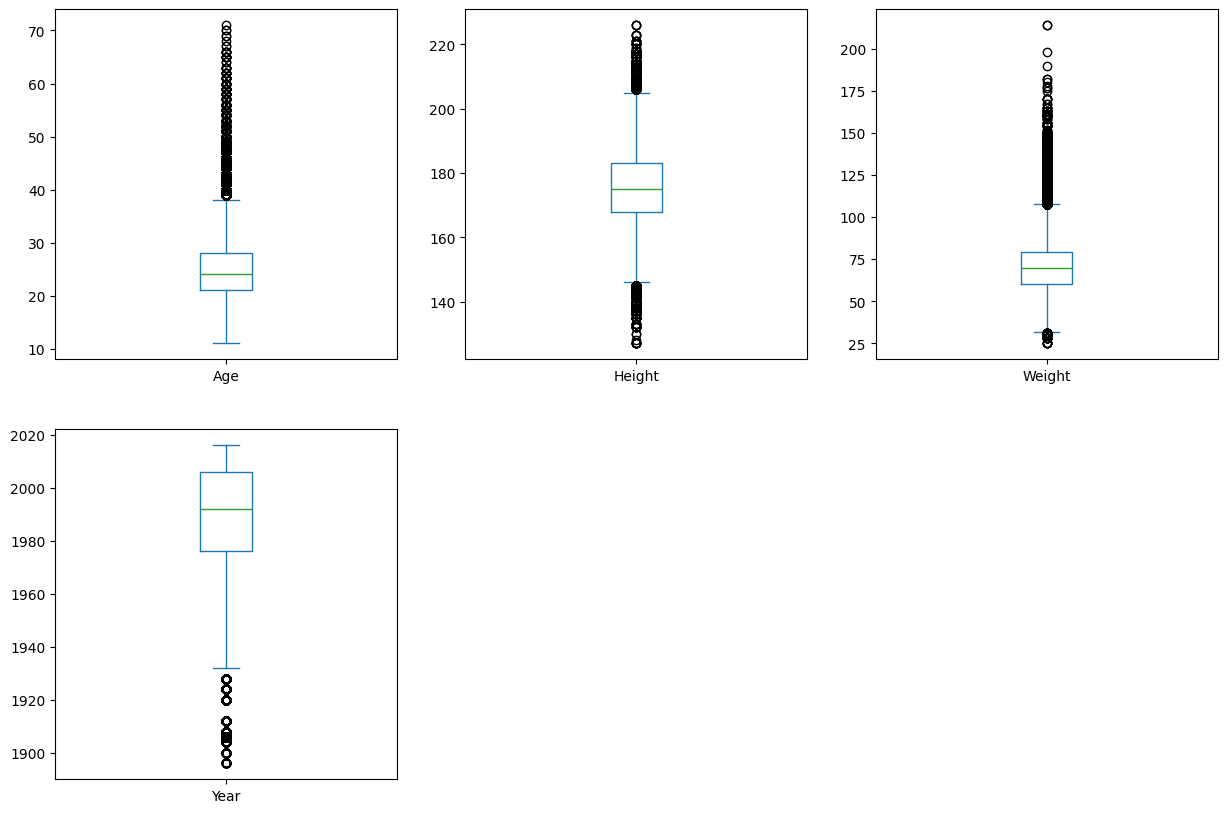

In [17]:
df.select_dtypes('number').plot(
    kind='box',
    subplots=True,
    layout=(int(len(df.select_dtypes('number').columns)/3)+1, 3),  # organiza en filas y 3 columnas
    figsize=(15, 10),
    grid=False
)

In [18]:
df.select_dtypes('number').corr()

,Age,Height,Weight,Year
Age,1.000000,0.141563,0.211999,0.089552
Height,0.141563,1.000000,0.796448,0.048310
Weight,0.211999,0.796448,1.000000,0.022270
Year,0.089552,0.048310,0.022270,1.000000


<Axes: >

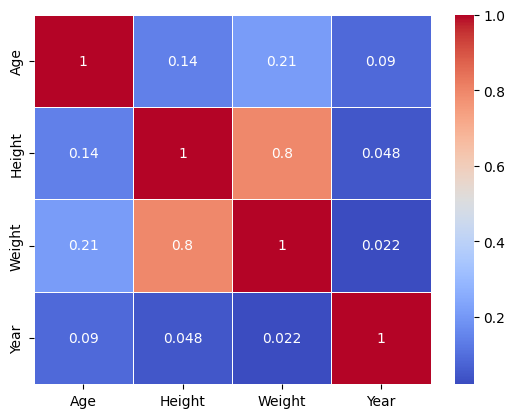

In [19]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm', linewidths=0.5)

#### <span style="color:cyan">Analizando el histograma solo Height es una variable normal

#### <span style="color:cyan">En los boxplot se puede ver que hay varias variables con datos atipicos como: Age tiene gran variedad de datos atipicos en la parte superior, Height tiene aproximadamente la misma cantidad en su parte superior e inferior, Weight tiene más datos atipicos en la parte superior y pocos en la parte inferior y Year solo tiene unos pocos datos atipicos en la parte inferior.

#### <span style="color:cyan">Luego analizando las correlaciones se puede comprobar que Height tiene valores más cercanos a 1 lo cual indica que es una variable buena para predecir y también se puede notar que es una buena predictora para Weight, mientras que las variables Age y Year no son tan buenas predictoras, ya que sus valores son más bajos y esto nos puede ayudar a analizar un poco más que no deberían incluirsen en la matriz de caracteristicas.

#### <span style="color:cyan">Las variables que no son aptas para usar en la matriz de caracteristicas son Medal, City y Season.


## Entrenamiento del modelo

Entrene un modelo de árbol de decisión que prediga la variable **Weight**.

Procese las variables de acuerdo con los análisis de variables cuantitativas y categóricas hechos previamente. Este procesamiento debe empaquetarse usando `ColumnTransformer`, para que los datos de entrenamiento y prueba sean procesados por separado.

Reporte los `scores` de entrenamiento y prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del preprocesamiento.

In [20]:
df = df.drop(columns=['Age', 'Medal', 'Year', 'Season', 'City'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205846 entries, 0 to 271115
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     205846 non-null  object 
 1   Height  205846 non-null  int64  
 2   Weight  205846 non-null  float64
 3   Team    205846 non-null  object 
 4   Sport   205846 non-null  object 
 5   Event   205846 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 11.0+ MB


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(['Weight'], axis=1)
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')


Tamaño del conjunto de entrenamiento es: (144092, 5)
Tamaño del conjunto de prueba es: (61754, 5)


In [22]:
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

ss = StandardScaler() 
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') 

oheCityCardinalidadAlta = OneHotEncoder(
    sparse_output=False,
    max_categories=6,
    handle_unknown='ignore'
)

oheNominalNormal = OneHotEncoder(
    sparse_output=False,
    drop='first'
    )


In [23]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num_prep', ss, ['Height' ]),
    ('cod_binary', ohe, ['Sex']),
    ('cod_cardinalidad', oheCityCardinalidadAlta, ['Team', 'Event']),
    ('cod_nominal', oheNominalNormal, ['Sport'])

    ], remainder='drop') 

In [24]:
preprocessor

,transformers,"[('num_prep', ...), ('cod_binary', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [25]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [26]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=1
    )

tree.fit(X_train_prep, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
print(f'Accuracy en el conjunto de entrenamiento: {tree.score(X_train_prep, y_train)}')
print(f'Accuracy en el conjunto de prueba: {tree.score(X_test_prep, y_test)}')

Accuracy en el conjunto de entrenamiento: 0.6782385299829212
Accuracy en el conjunto de prueba: 0.674952075777476


In [28]:
print(preprocessor.get_feature_names_out())

['num_prep__Height' 'cod_binary__Sex_M' 'cod_cardinalidad__Team_Canada'
 'cod_cardinalidad__Team_France' 'cod_cardinalidad__Team_Great Britain'
 'cod_cardinalidad__Team_Italy' 'cod_cardinalidad__Team_United States'
 'cod_cardinalidad__Team_infrequent_sklearn'
 "cod_cardinalidad__Event_Basketball Men's Basketball"
 "cod_cardinalidad__Event_Football Men's Football"
 "cod_cardinalidad__Event_Hockey Men's Hockey"
 "cod_cardinalidad__Event_Ice Hockey Men's Ice Hockey"
 "cod_cardinalidad__Event_Water Polo Men's Water Polo"
 'cod_cardinalidad__Event_infrequent_sklearn' 'cod_nominal__Sport_Archery'
 'cod_nominal__Sport_Art Competitions' 'cod_nominal__Sport_Athletics'
 'cod_nominal__Sport_Badminton' 'cod_nominal__Sport_Baseball'
 'cod_nominal__Sport_Basketball' 'cod_nominal__Sport_Beach Volleyball'
 'cod_nominal__Sport_Biathlon' 'cod_nominal__Sport_Bobsleigh'
 'cod_nominal__Sport_Boxing' 'cod_nominal__Sport_Canoeing'
 'cod_nominal__Sport_Cross Country Skiing' 'cod_nominal__Sport_Curling'
 'cod_

#### <span style="color:cyan">Para el modelo analizando que Weight es una variable numerica y continua se puede usar un arbol de decisión DecisionTreeRegressor